# EDA — Feature Distributions & Class Separation

Use this notebook to visually tune distribution parameters in
`ml/synthetic/distributions.py` until fraud/normal classes overlap
realistically.

**Target overlap (fraud_below_normal_p95):**
- `amount` → **25–40%** (6 diverse fraud patterns, 2 of which use
  normal-range amounts — mule_fraud uses `generate_normal_amount`,
  balance_drain_fraud uses balance fraction; broader fraud set =
  wider natural overlap)
- engineered features (`sender_daily_amount_sum`, `days_since_last_tx`,
  `amount_to_balance_ratio`) → **5–15%**
- binary count features (`tx_last_hour`, `receiver_tx_count_24h`) →
  **~0%** (expected by design — normal is almost always 0)

In [1]:
import os, sys, json
from pathlib import Path

os.chdir(Path(os.getcwd()).resolve())
if os.path.basename(os.getcwd()) in ("notebooks", "ml"):
    os.chdir("..")
if "ml" not in os.listdir("."):
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ml.synthetic import config
from ml.synthetic.build_dataset import build_dataset

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
accounts_df, transactions_df = build_dataset()
print(f"Accounts: {len(accounts_df)}, Transactions: {len(transactions_df)}")
print(f"Fraud ratio: {transactions_df['is_fraud'].mean():.2%}")

Accounts: 2000, Transactions: 20000
Fraud ratio: 3.00%


In [3]:
def overlap_metrics(feature: str, df: pd.DataFrame) -> dict:
    normal = df.loc[~df["is_fraud"], feature]
    fraud = df.loc[df["is_fraud"], feature]
    p95 = normal.quantile(0.95)
    fraud_below_p95 = (fraud < p95).mean() * 100
    return {
        "feature": feature,
        "normal_mean": normal.mean(),
        "fraud_mean": fraud.mean(),
        "normal_median": normal.median(),
        "fraud_median": fraud.median(),
        "normal_p95": p95,
        "fraud_below_normal_p95(%)": round(fraud_below_p95, 2),
    }

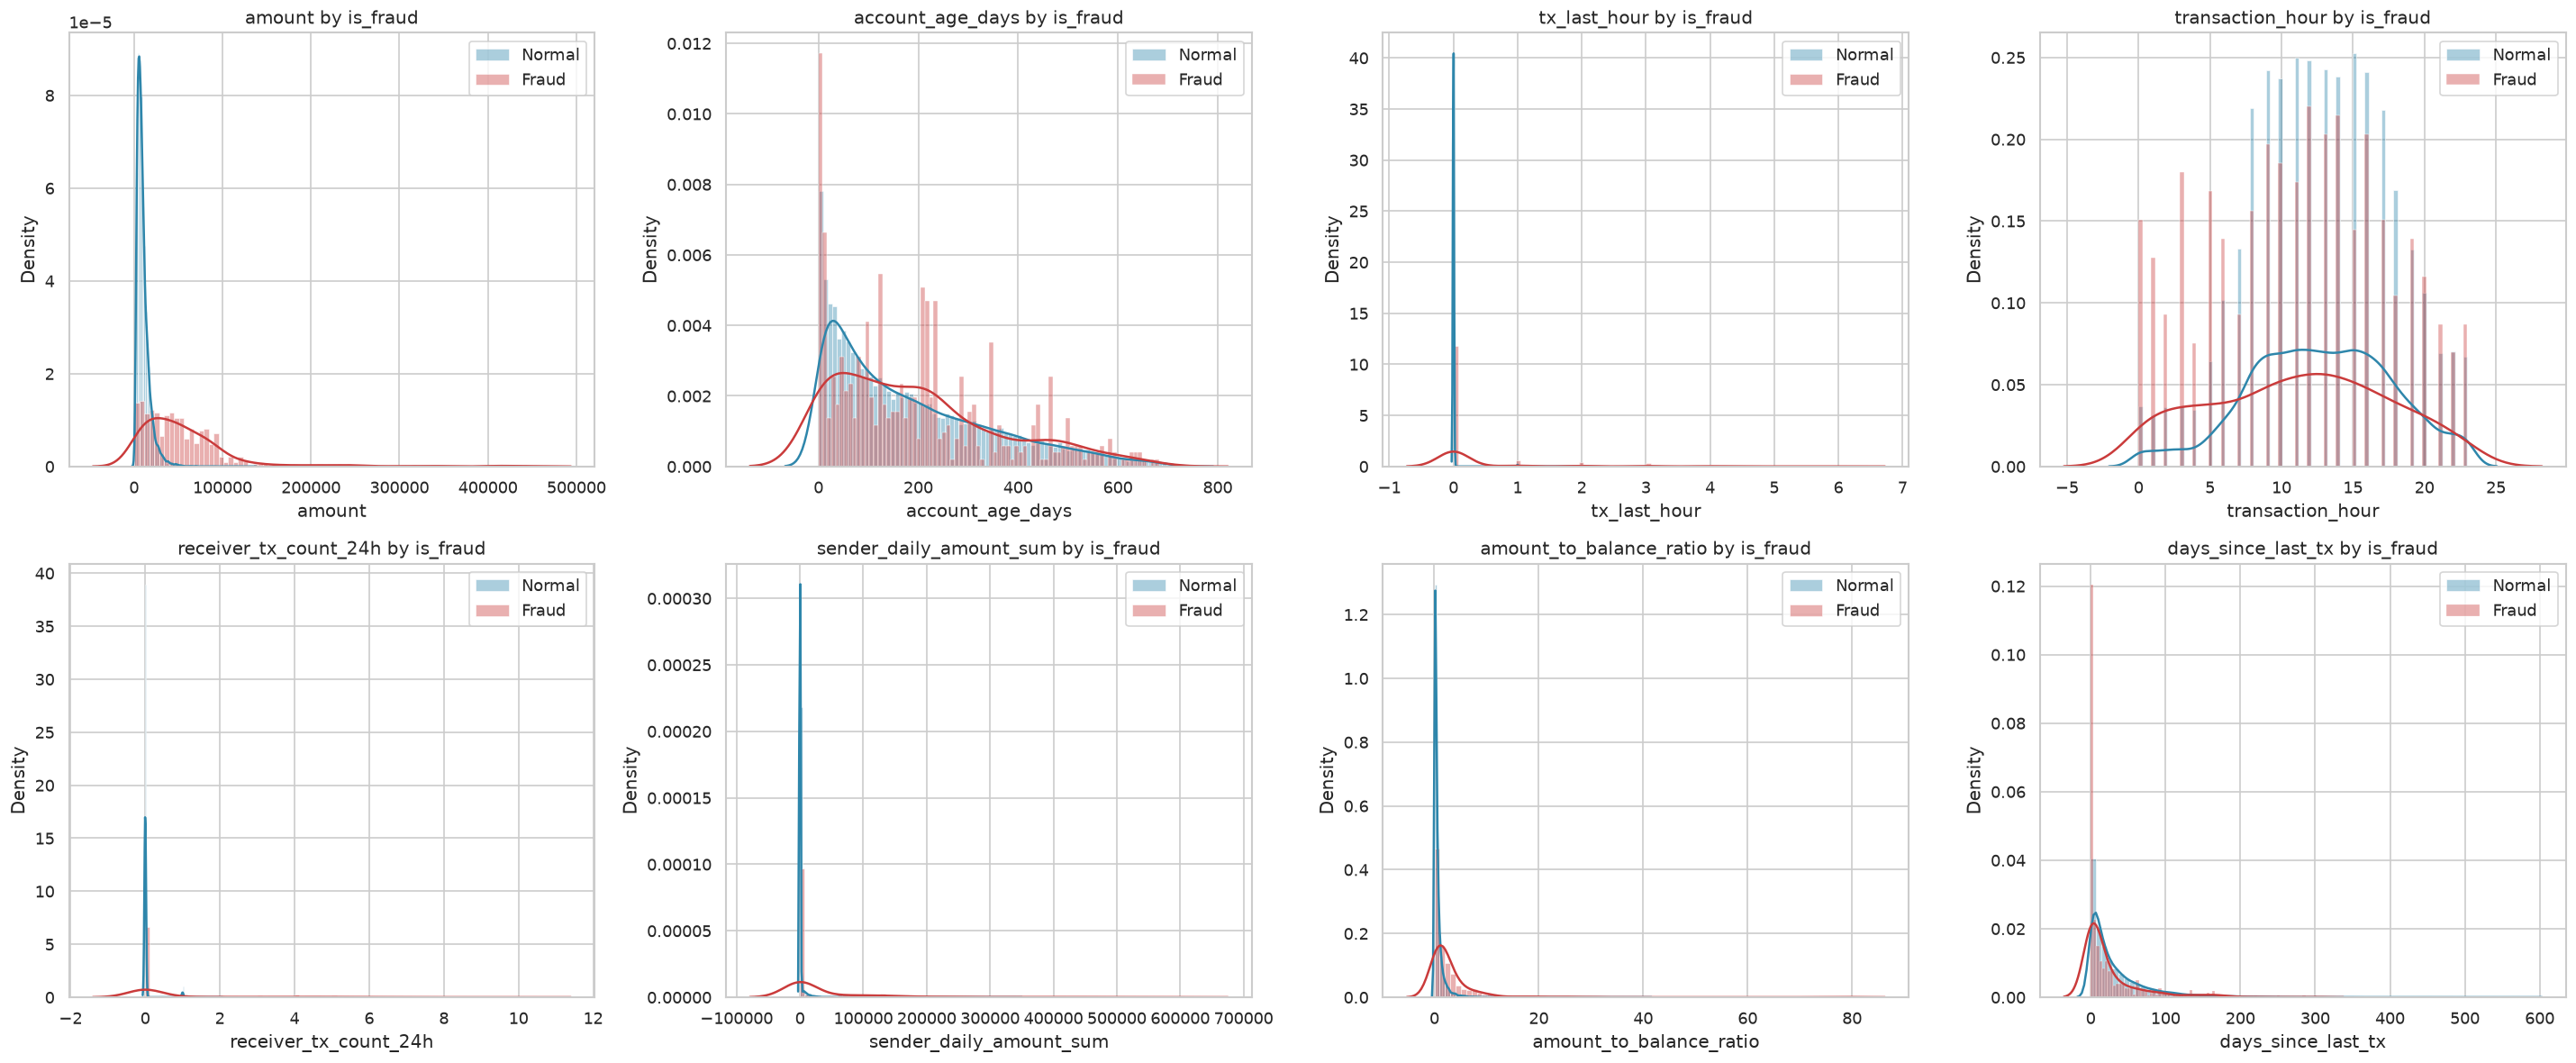

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
features = ["amount", "account_age_days", "tx_last_hour", "transaction_hour", "receiver_tx_count_24h", "sender_daily_amount_sum", "amount_to_balance_ratio", "days_since_last_tx"]
axes = axes.flatten()
colors = {False: "#2e86ab", True: "#ca3b3b"}
labels = {False: "Normal", True: "Fraud"}

for ax, feat in zip(axes[:len(features)], features):
    for is_fraud in [False, True]:
        subset = transactions_df[transactions_df["is_fraud"] == is_fraud][feat]
        sns.histplot(
            subset, bins=80, color=colors[is_fraud], label=labels[is_fraud],
            stat="density", alpha=0.4, edgecolor=None, ax=ax,
        )
        sns.kdeplot(subset, color=colors[is_fraud], linewidth=1.5, ax=ax)
    ax.set_title(f"{feat} by is_fraud")
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.legend()

for ax in axes[len(features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [5]:
metrics = pd.DataFrame(
    [overlap_metrics(feat, transactions_df) for feat in features]
)
metrics

,feature,normal_mean,fraud_mean,normal_median,fraud_median,normal_p95,fraud_below_normal_p95(%)
0,amount,10068.110613,55628.374400,8127.14500,43951.175000,23898.776000,29.33
1,account_age_days,182.557835,195.421667,137.00000,164.500000,509.000000,94.17
2,tx_last_hour,0.004227,0.273333,0.00000,0.000000,0.000000,0.00
3,transaction_hour,12.741289,11.136667,13.00000,11.500000,21.000000,93.00
4,receiver_tx_count_24h,0.026443,0.633333,0.00000,0.000000,0.000000,0.00
5,sender_daily_amount_sum,988.367402,42159.673867,0.00000,0.000000,5049.493500,71.50
6,amount_to_balance_ratio,0.643317,3.082285,0.30940,1.200200,2.301605,67.33
7,days_since_last_tx,33.419212,24.711920,17.86353,5.606736,117.889301,94.50


In [6]:
print("=== Per-feature overlap check ===\n")

TARGET_RANGES = {
    "amount": (25, 40),
    "account_age_days": (5, 15),
    "tx_last_hour": None,         # N/A — binary count feature, 0% expected
    "transaction_hour": (5, 15),
    "receiver_tx_count_24h": None,  # N/A — binary count feature, 0% expected
    "sender_daily_amount_sum": (5, 15),
    "amount_to_balance_ratio": (5, 15),
    "days_since_last_tx": (5, 15),
}

for _, row in metrics.iterrows():
    feat = row["feature"]
    ov = row["fraud_below_normal_p95(%)"]
    tr = TARGET_RANGES.get(feat)
    if tr is None:
        status = "N/A (binary count — ~0% expected)"
    elif ov < tr[0]:
        status = f"WARNING: {ov:.1f}% < {tr[0]}% — too little overlap"\
                 f", classes too separable"
    elif ov > tr[1]:
        status = f"INFO: {ov:.1f}% > {tr[1]}% — high overlap,"\
                 f" check for excessive noise"
    else:
        status = f"OK: {ov:.1f}% in [{tr[0]}%, {tr[1]}%]"
    print(f"  {feat:35s}  {ov:6.1f}%  {status}")

=== Per-feature overlap check ===

  amount                                 29.3%  OK: 29.3% in [25%, 40%]
  account_age_days                       94.2%  INFO: 94.2% > 15% — high overlap, check for excessive noise
  tx_last_hour                            0.0%  N/A (binary count — ~0% expected)
  transaction_hour                       93.0%  INFO: 93.0% > 15% — high overlap, check for excessive noise
  receiver_tx_count_24h                   0.0%  N/A (binary count — ~0% expected)
  sender_daily_amount_sum                71.5%  INFO: 71.5% > 15% — high overlap, check for excessive noise
  amount_to_balance_ratio                67.3%  INFO: 67.3% > 15% — high overlap, check for excessive noise
  days_since_last_tx                     94.5%  INFO: 94.5% > 15% — high overlap, check for excessive noise


## How to tune

1. Open `ml/synthetic/distributions.py`.
2. Adjust `generate_normal_amount` / `generate_fraud_amount`
   (they use `rng.lognormal(mean, sigma)`).
   Higher sigma = wider spread = more overlap.
3. Adjust `generate_balance` to control `amount_to_balance_ratio`.
4. **Restart & Run All** — dataset rebuilds deterministically (SEED=42).
5. Check per-feature overlap table; target ranges differ by feature type.
6. Export final dataset: `python ml/synthetic/export_dataset.py`